In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


sns.set_style("whitegrid")

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
def get_file(path):
    """
    recupère le fichier csv donnée avec le séparateur ';' et retourne un dataFrame.
    
    Args:
        path (str): Le chemin vers le fichier CSV.
        
    Returns:
        pd.DataFrame: Les données chargées.
    """
    
    #ouvir le fichier en dataframe
    df = pd.read_csv(path, sep=';')

    return df


In [ ]:
def numerise_col(df, col):
    """
    recupere une colonne d'un dataframe et passe tout ses valeurs en float

    Args:
        df(pd.DataFrame): le dataframe à nettoyer
        col(str): le nom de la colonne
    """
    
    #passer la variable en srting pour pouvoir les manipuler
    df[col] = df[col].astype(str)

    #on transforme les , en .
    df[col] = df[col].str.replace(",", ".")

    #on supprime tous ce qui n'est pas des chiffres de 0 a 9 et .
    df[col] = df[col].str.replace(r'[^0-9]', '')

    #conversion en float
    df[col] = pd.to_numeric(df[col])

    #NA remplacé les vides par 0
    df[col] = df[col].fillna(0)

    #arrondir 2 chiffres
    df[col] = df[col].round(2)

In [ ]:
def clean_data(df):
    """
    nettoie le dataframe en supprimant les doublons et les lignes avec des 
    informations manquantes des principales information.
    
    Args:
        df (pd.DataFrame): le dataframe à nettoyer.
    """
    
    #supprime toutes les donnée dupliquées"
    df = df.drop_duplicates()

    #changer le format de la date pour qu'elle soit plus manipulable et met NaN si la date est pas bonne
    df['Date_dt'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
    
    #supprime toutes les donnée ou Date, Gare de depart ou Gare d'arrivée ne sont pas rempli
    df = df.dropna(subset=['Date', 'Gare de départ', "Gare d'arrivée"])

    #colonnes de texte
    cols_non_numerique = [
        'Date', 
        'Service', 
        'Gare départ', 
        "Gare d'arrivée",
        'Commentaire annulations',
        "Commentaire retards au départ",
        "Commentaire retards a l'arrivée"
    ]

    #boucle pour clean les colonnes numerique
    for col in df.columns:
        if col not in cols_non_numerique:
            numerise_col(df, col)

    """
    autres clean a faire : 
        - ajouter des collones au df.dropna au dessu si neccecaire
        - si vous avez d'autres idée je vous laisse faire GL
    """
    
    #revoie les données nettoyée de la dataframe
    return(df)

In [ ]:
def save_df(df):
    """
    crée un fichier cleaned_dataset.csv ou stocker le dataframe en csv

    Args:
        df (pd.DataFrame): le dataframe à stocker
    """
    df.to_csv('cleaned_dataset.csv', index=False)


In [ ]:
def aff_graph(valX, valY, labelX, labelY, title = None):
    """
    Affiche un graphique avec les valeurs donnée.
    Args:
        valX: données de l'axe x
        valY : données de l'axe y
        labelX: Nom de l'axe x
        labelY : Nom de l'axe y
        title: le titre du graphiqie
    """
    if (not title):
         title = f'{labelY} par {labelX}'
    plt.figure(figsize=(12, 6))
    
    # Création du graphique en barres
    plt.plot(valX, valY, 'o-', color='blue', linewidth=2)
    
    # Ajout des labels et du titre
    plt.xlabel(labelX, fontweight='bold')
    plt.ylabel(labelY, fontweight='bold')
    plt.title(title, fontsize=14)
    
    # Rotation des noms sur l'axe X 
    plt.xticks(rotation=45, ha='right')
    
    # Ajout d'une grille
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
    

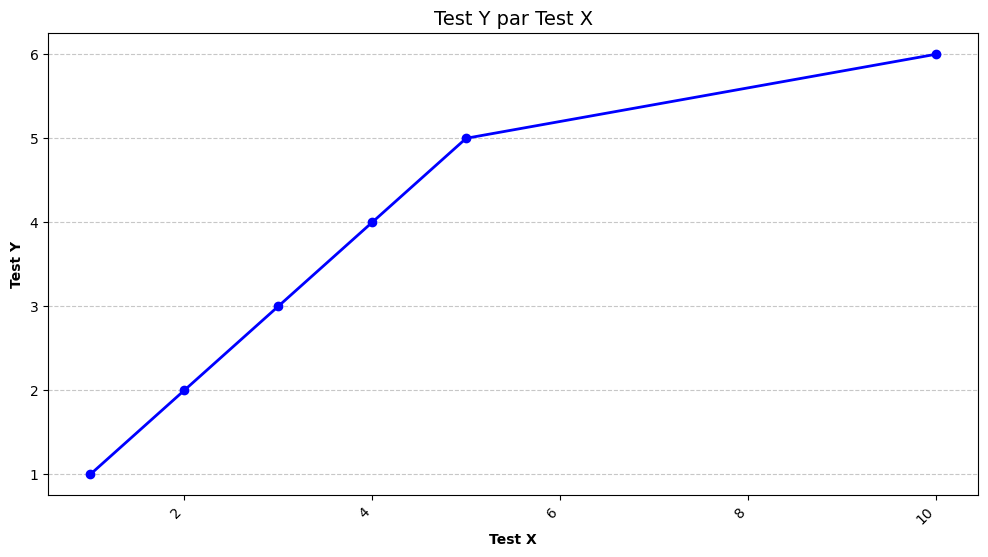

In [ ]:
aff_graph([1,2,3,4,5,10],[1,2,3,4,5,6], "Test X","Test Y")

## Graphique 1

In [ ]:
# Distribution des retards
delay_col = "Retard moyen des trains en retard au départ"
df[delay_col].describe()

plt.figure(figsize=(8,5))
sns.histplot(df[delay_col], bins=30, kde=True)
plt.title("Distribution des retards")
plt.show()

NameError: name 'df' is not defined

## Graphique 2

In [ ]:
# Retard moyen par gare
df.groupby("Gare de départ")[delay_col].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Retard moyen par gare de départ")
plt.show()

## Graphique 3

In [ ]:
# Retard moyen par mois
df["month"] = df["Date_dt"].dt.month

df.groupby("month")[delay_col].mean().plot(kind="bar")
plt.title("Retard moyen par mois")
plt.show()